# Exploratory Data Analysis

This notebook performs EDA only and does not train any model. The goal is to inspect the `target` distribution for the heart disease dataset, review basic data structure, missing values, numeric feature histograms, and the correlation heatmap.

In [14]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="muted")

# Read data, prefer data/raw/heart.csv
base_path = Path("..") / "data" / "raw"
primary_path = base_path / "heart.csv"
fallback_path = base_path / "heart_disease_uci.csv"

if primary_path.exists():
    data_path = primary_path
    print(f"Using primary data path: {data_path}")
elif fallback_path.exists():
    data_path = fallback_path
    print(f"Primary path {primary_path} not found. Using fallback data path: {data_path}")
else:
    raise FileNotFoundError(
        "Data file not found. Please place heart.csv in data/raw or provide heart_disease_uci.csv in data/raw."
    )

# Read the CSV file
try:
    df = pd.read_csv(data_path)
except Exception as exc:
    raise RuntimeError(f"Failed to read data from {data_path}: {exc}")

print(f"Loaded data with shape: {df.shape}")
print("Columns:")
print(df.columns.tolist())
print()
print("Column data types:")
print(df.dtypes)


Primary path ..\data\raw\heart.csv not found. Using fallback data path: ..\data\raw\heart_disease_uci.csv
Loaded data with shape: (920, 16)
Columns:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Column data types:
id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object


## 1. Data Overview

Review the dataset shape, first rows, data types, and statistical summary.

In [15]:
# Data overview
print("Shape:")
print(df.shape)
print()
print("Head:")
print(df.head())
print()
print("Info:")
df.info()
print()
print("Describe:")
print(df.describe(include="all"))

Shape:
(920, 16)

Head:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4           

## 2. Missing Value Check

Check the number of missing values for each column.

In [16]:
missing = df.isnull().sum()
print(missing)

if missing.sum() == 0:
    print("\nNo missing values were found.")
else:
    print(f"\nTotal missing values: {missing.sum()}")

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Total missing values: 1759


## 3. Target Distribution

Inspect the class distribution of the `target` column and plot a bar chart. The target column is assumed to be named `target`.

Using 'num' as the target column because 'target' is not present.
num counts:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

num distribution (%):
num
0    44.67
1    28.80
2    11.85
3    11.63
4     3.04
Name: proportion, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20712\2705122806.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_series.index.astype(str), y=count_series.values, palette="pastel")


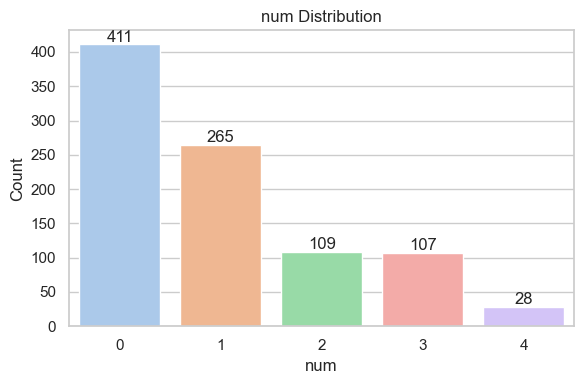


Binary target derived from num > 0:
num
disease       509
no disease    411
Name: count, dtype: int64

Binary target distribution (%):
num
disease       55.33
no disease    44.67
Name: proportion, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20712\2705122806.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=binary_counts.index, y=binary_counts.values, palette="pastel")


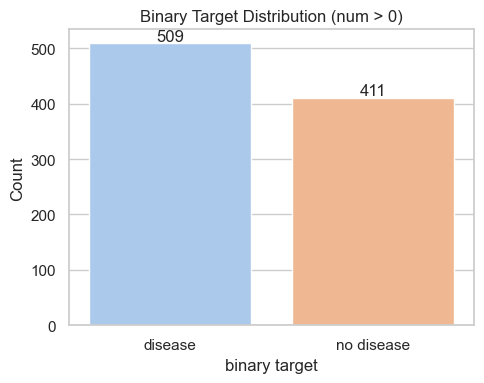

In [17]:
target_column = "target" if "target" in df.columns else ("num" if "num" in df.columns else None)
if target_column is None:
    raise KeyError("The dataset does not contain a 'target' or 'num' column. Please check the input file.")

if target_column != "target":
    print(f"Using '{target_column}' as the target column because 'target' is not present.")

count_series = df[target_column].value_counts(dropna=False)
norm_series = df[target_column].value_counts(normalize=True, dropna=False)

print(f"{target_column} counts:")
print(count_series)
print()
print(f"{target_column} distribution (%):")
print((norm_series * 100).round(2))

plt.figure(figsize=(6, 4))
sns.barplot(x=count_series.index.astype(str), y=count_series.values, palette="pastel")
plt.title(f"{target_column} Distribution")
plt.xlabel(target_column)
plt.ylabel("Count")
for index, value in enumerate(count_series.values):
    plt.text(index, value + max(count_series.values) * 0.01, str(value), ha="center")
plt.tight_layout()
plt.show()

if target_column == "num" and count_series.index.nunique() > 2:
    binary_series = (df[target_column] > 0).map({False: "no disease", True: "disease"})
    binary_counts = binary_series.value_counts()
    binary_ratio = binary_series.value_counts(normalize=True)

    print("\nBinary target derived from num > 0:")
    print(binary_counts)
    print()
    print("Binary target distribution (%):")
    print((binary_ratio * 100).round(2))

    plt.figure(figsize=(5, 4))
    sns.barplot(x=binary_counts.index, y=binary_counts.values, palette="pastel")
    plt.title("Binary Target Distribution (num > 0)")
    plt.xlabel("binary target")
    plt.ylabel("Count")
    for index, value in enumerate(binary_counts.values):
        plt.text(index, value + max(binary_counts.values) * 0.01, str(value), ha="center")
    plt.tight_layout()
    plt.show()


## 4. Basic Visualization

Plot histograms for numeric features and a feature correlation heatmap.

Numeric columns (8): ['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']
Feature columns used for visualization (7): ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']


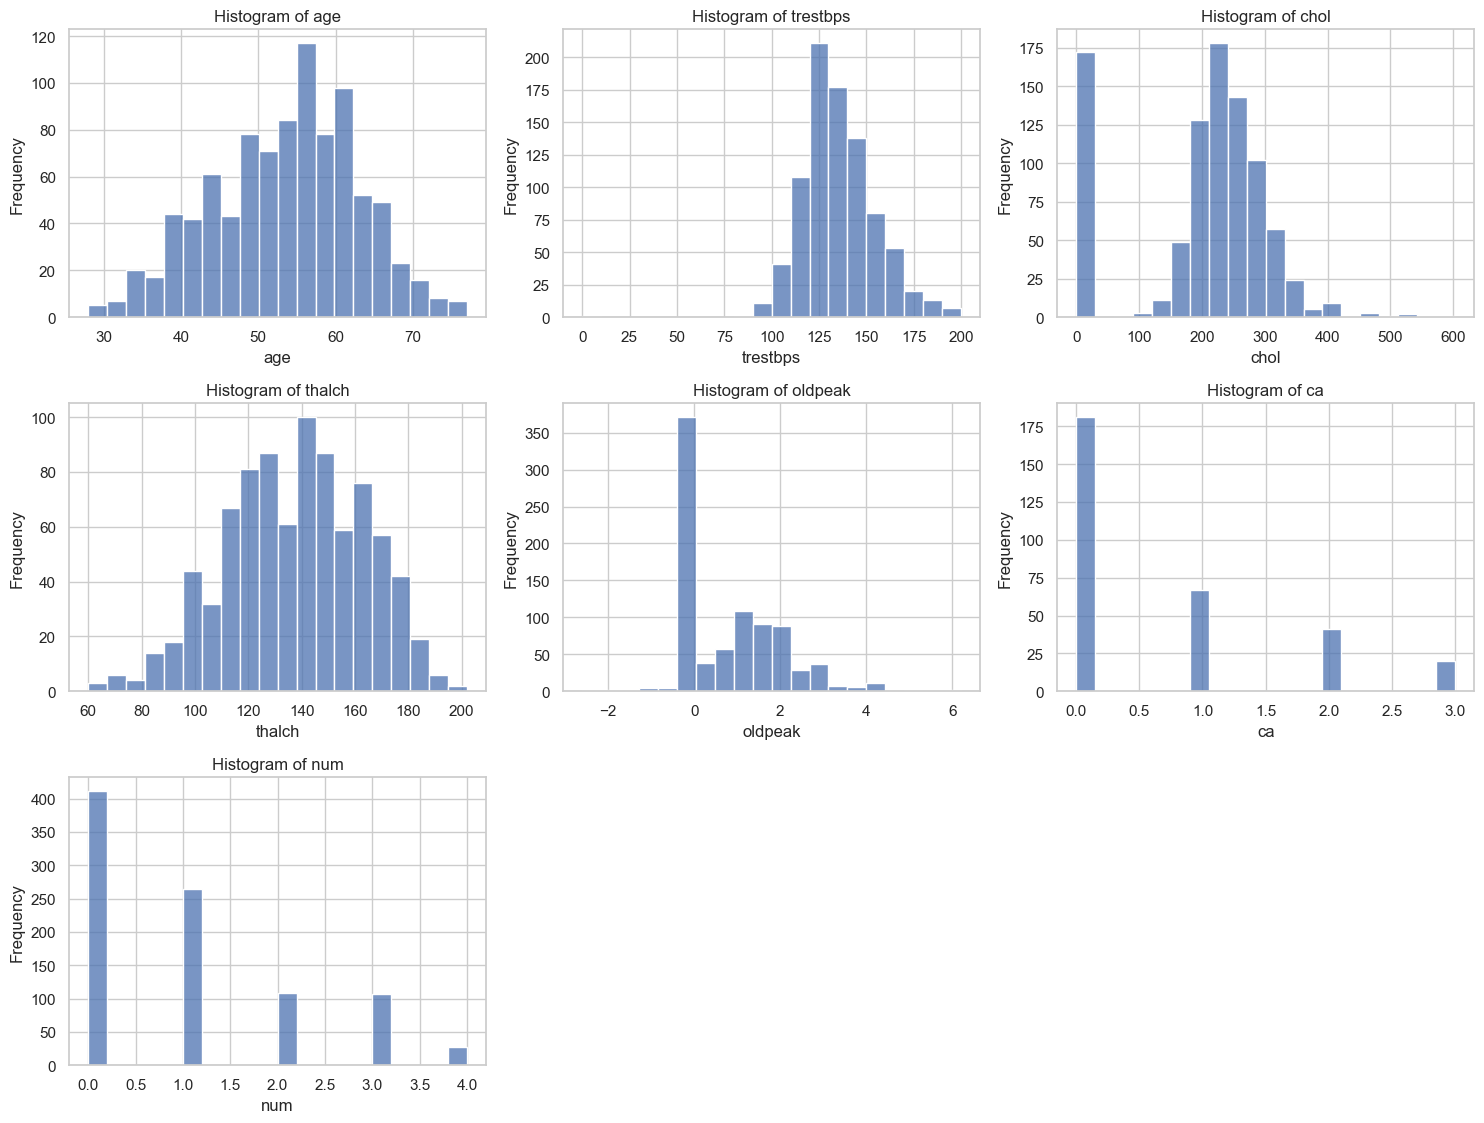

In [18]:
numeric_columns = df.select_dtypes(include=["number"]).columns.tolist()
feature_columns = [col for col in numeric_columns if col != "id"]
print(f"Numeric columns ({len(numeric_columns)}): {numeric_columns}")
print(f"Feature columns used for visualization ({len(feature_columns)}): {feature_columns}")

# Plot histograms for numeric features excluding identifier columns like id
num_plots = len(feature_columns)
cols = 3
rows = (num_plots + cols - 1) // cols
plt.figure(figsize=(cols * 5, rows * 3.8))
for i, column in enumerate(feature_columns, start=1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[column].dropna(), kde=False, bins=20, color="#4c72b0")
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

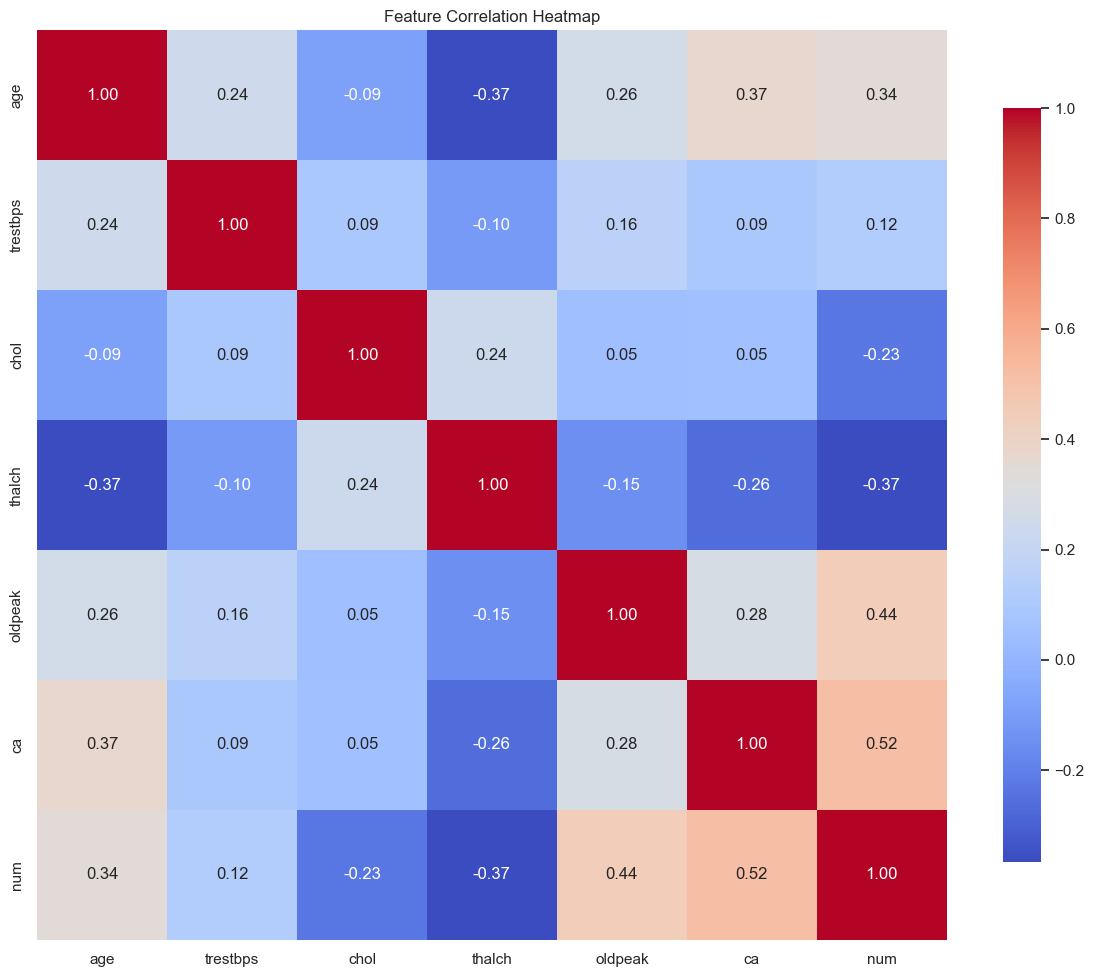

In [19]:
# Correlation heatmap (exclude identifier columns such as id)
corr = df[feature_columns].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [20]:
# Summarize EDA findings
target_column = "target" if "target" in df.columns else ("num" if "num" in df.columns else None)
num_rows, num_cols = df.shape
missing = df.isnull().sum()
categorical_candidates = [col for col in ["cp", "sex", "dataset", "fbs", "restecg", "exang", "slope", "ca", "thal"] if col in df.columns]

print(f"Dataset shape: {num_rows} rows, {num_cols} columns")
print()

if target_column:
    target_counts = df[target_column].value_counts(dropna=False)
    target_ratio = df[target_column].value_counts(normalize=True, dropna=False)
    print(f"Target column: {target_column}")
    print("Target counts:")
    print(target_counts)
    print()
    print("Target ratio (%):")
    print((target_ratio * 100).round(2))
    if target_column == "num" and target_counts.index.nunique() > 2:
        binary_counts = (df[target_column] > 0).value_counts()
        binary_ratio = (df[target_column] > 0).value_counts(normalize=True)
        print()
        print("Binary target derived from num > 0:")
        print(binary_counts)
        print()
        print("Binary target ratio (%):")
        print((binary_ratio * 100).round(2))
else:
    print("No target column found for summary.")

print()
print(f"Missing values total: {missing.sum()}")
print(missing[missing > 0])
print()
print("Potential categorical columns:")
print(categorical_candidates)
print()
print("Binary classification suitability:")
print("The dataset can support binary classification if 'num' is used as disease vs no disease when applicable.")


Dataset shape: 920 rows, 16 columns

Target column: num
Target counts:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Target ratio (%):
num
0    44.67
1    28.80
2    11.85
3    11.63
4     3.04
Name: proportion, dtype: float64

Binary target derived from num > 0:
num
True     509
False    411
Name: count, dtype: int64

Binary target ratio (%):
num
True     55.33
False    44.67
Name: proportion, dtype: float64

Missing values total: 1759
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64

Potential categorical columns:
['cp', 'sex', 'dataset', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Binary classification suitability:
The dataset can support binary classification if 'num' is used as disease vs no disease when applicable.


### EDA Summary

- The dataset shape is shown by the code output above.
- The actual target column is `num` if `target` is not present; `num` contains multiple disease severity levels.
- Missing values have been inspected. If no values are printed, the dataset has no missing values.
- Potential categorical features include `cp`, `sex`, `dataset`, `fbs`, `restecg`, `exang`, `slope`, `ca`, and `thal`.
- The dataset can support binary classification if `num > 0` is used to represent heart disease versus no disease.
